In [1]:
%load_ext autoreload
%autoreload 2
import os
import math

import matplotlib.pyplot as plt
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm
import numpy as np
from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import sample_8gaussians, sample_moons, torch_wrapper

savedir = "models/2d"
os.makedirs(savedir, exist_ok=True)

In [2]:
def eight_normal_sample(n, dim=2, scale=5, var=0.3):
    m = torch.distributions.multivariate_normal.MultivariateNormal(
        torch.zeros(dim), var * torch.eye(dim)
    )
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    noise = m.sample((n,))
    multi = torch.multinomial(torch.ones(8), n, replacement=True)
    data = []
    for i in range(n):
        data.append(centers[multi[i]] + noise[i])
    data = torch.stack(data)
    return data
    
def eight_normal_log_prob(x, dim=2, scale=5, var=0.3):
    centers = [
        (1, 0),
        (-1, 0),
        (0, 1),
        (0, -1),
        (1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), 1.0 / np.sqrt(2)),
        (-1.0 / np.sqrt(2), -1.0 / np.sqrt(2)),
    ]
    centers = torch.tensor(centers) * scale
    
    # Compute per-component densities
    sigma2 = var
    normalization = -0.5 * dim * torch.log(2 * torch.tensor(np.pi) * sigma2)
    log_probs = []
    for center in centers:
        log_prob = normalization - torch.sum((x - center) ** 2, dim=-1) / (2 * sigma2)
        log_probs.append(log_prob)
    log_probs = torch.stack(log_probs, dim=-1)
    # Log-sum-exp trick for numerical stability
    max_log_prob, _ = torch.max(log_probs, dim=-1, keepdim=True)
    mixture_log_prob = max_log_prob + torch.log(torch.sum(torch.exp(log_probs - max_log_prob), dim=-1, keepdim=True)) - torch.log(torch.tensor(len(centers))).squeeze()
    return mixture_log_prob

class torch_wrapper(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x, *args, **kwargs):
        return self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))

class torch_shortcut_wrapper(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x, *args, **kwargs):
        dt_base_bootstrap = torch.zeros_like(t)
        return self.model(torch.cat([x, 
                                     t.repeat(x.shape[0])[:, None], 
                                    dt_base_bootstrap.repeat(x.shape[0])[:, None]], 1))


def exact_div_fn(u):
    """Accepts a function u:R^D -> R^D."""
    J = torch.func.jacrev(u)
    jac = lambda x, *args: J(x)
    return jac
    # return lambda x, *args: torch.trace(J(x))


def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn


class cnf_wrapper(torch.nn.Module):
    """Wraps model to a torchdyn compatible CNF format.
    Appends an additional dimension representing the change in likelihood
    over time.
    """

    def __init__(self, model, likelihood_estimator="exact"):
        super().__init__()
        self.model = model
        self.div_fn, self.eps_fn = self.get_div_and_eps(likelihood_estimator)

    def get_div_and_eps(self, likelihood_estimator):
        if likelihood_estimator == "exact":
            return exact_div_fn, None
        if likelihood_estimator == "hutch_gaussian":
            return div_fn_hutch_trace, torch.randn_like
        if likelihood_estimator == "hutch_rademacher":

            def eps_fn(x):
                return torch.randint_like(x, low=0, high=2).float() * 2 - 1.0

            return div_fn_hutch_trace, eps_fn
        raise NotImplementedError(
            f"likelihood estimator {likelihood_estimator} is not implemented"
        )

    def forward(self, t, x, *args, **kwargs):
        t = t.squeeze()
        x = x[..., :-1]

        def vecfield(y):
            return self.model(torch.cat([y, t[None]]))

        if self.eps_fn is None:
            div = torch.vmap(self.div_fn(vecfield))(x)
        else:
            div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        dx = self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))
        return torch.cat([dx, div[:, None]], dim=-1)

In [3]:
def plot_trajectories_sb(traj, legend=True, logp=None):
    n = 2000
    plt.figure(figsize=(10, 10))
    plt.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    plt.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    if logp is None:
        plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")
    else:
        plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c=logp.detach())
        
    for i in range(5, 15):
        plt.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    plt.xticks([])
    plt.yticks([])
    plt.axis("off")

In [4]:
class MLP3(torch.nn.Module):
    def __init__(self, dim, out_dim=None, w=64):
        super().__init__()
        
        if out_dim is None:
            out_dim = dim
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + 2, w),
            torch.nn.ReLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, out_dim),
        )

    def forward(self, x):
        return self.net(x)

In [5]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
device = "cpu"
batch_size = 512
sigma = 0
dim = 2
model = MLP3(dim=dim, w=64)
optimizer = torch.optim.AdamW(model.parameters(), 0.01, weight_decay=0.1)
eps = 1e-2
k = batch_size // 4
M = 128
bootstrap_every = 8
log2_sections = np.log2(M).astype(np.int32)
num_iterations = 40_000

In [6]:
import torch
import torch.nn.functional as F
import numpy as np
import pdb

def get_targets(model,
                images, 
                force_t=-1, 
                force_dt=-1):

    device = images.device  # Or wherever you’d like your tensors to live (cuda, cpu, etc.)
    info = {}

    # -----------------------------------------------------------------
    #  1) =========== Sample dt. ============
    # -----------------------------------------------------------------
    bootstrap_batchsize = batch_size // bootstrap_every
    log2_sections = int(np.log2(M))

    dt_range = torch.arange(log2_sections, device=device, dtype=torch.int32)  # [0, 1, 2, ..., log2_sections-1]
    dt_array = (log2_sections - 1 - dt_range)  # e.g. [log2_sections-1, ..., 0]
    repeated = dt_array.repeat(bootstrap_batchsize // log2_sections)
    needed = bootstrap_batchsize - repeated.shape[0]
    dt_base = torch.cat([repeated, torch.zeros(needed, device=device, dtype=torch.int32)], dim=0)

    force_dt_vec = torch.ones(bootstrap_batchsize, device=device, dtype=torch.float32) * force_dt
    dt_base = dt_base.to(torch.float32)  # cast to float to match usage below
    dt_base = torch.where(force_dt_vec != -1, force_dt_vec, dt_base)  # if force_dt != -1, use that

    # dt = 1 / (2^(dt_base)) 
    dt = 1.0 / (2.0 ** dt_base)

    dt_base_bootstrap = dt_base + 1.0
    dt_bootstrap = dt / 2.0

    # -----------------------------------------------------------------
    #  2) =========== Sample t. ============
    # -----------------------------------------------------------------
    dt_sections = 2.0 ** dt_base

    # We want to sample t ~ Uniform{0, dt_sections[i]} (integer), then divide by dt_sections[i].
    # This is somewhat trickier to do in a single vectorized call in PyTorch 
    # (because each batch element can have a different max). 
    # We'll do it in a loop for clarity:

    t_list = []
    for i in range(bootstrap_batchsize):
        maxval = int(dt_sections[i].item())  # dt_sections[i] is float, convert to int
        # If maxval == 0 for some reason, clamp to 1 to avoid errors
        if maxval < 1:
            maxval = 1
        # Sample an integer in [0, maxval)
        t_i = torch.randint(low=0, high=maxval, size=(1,), device=device, dtype=torch.int64)
        t_list.append(t_i)

    t = torch.cat(t_list, dim=0).to(torch.float32)      # shape [bootstrap_batchsize]
    t = t / dt_sections                                 # elementwise scale to [0, 1]

    # force_t logic
    force_t_vec = torch.ones(bootstrap_batchsize, device=device, dtype=torch.float32) * force_t
    t = torch.where(force_t_vec != -1, force_t_vec, t)
    t_full = t.view(-1, 1)

    # -----------------------------------------------------------------
    #  3) =========== Generate Bootstrap Targets ============
    # -----------------------------------------------------------------
    x_1 = images[:bootstrap_batchsize]
    x_0 = torch.randn_like(x_1)
    x_t = (1.0 - (1.0 - 1e-5) * t_full) * x_0 + t_full * x_1

    with torch.no_grad():
        v_b1 = model(torch.cat([x_t, t[:, None], dt_base_bootstrap[:, None]], dim=-1))
    
    t2 = t + dt_bootstrap
    x_t2 = x_t + dt_bootstrap.view(-1, 1) * v_b1
    x_t2 = torch.clamp(x_t2, -4.0, 4.0)

    with torch.no_grad():
        v_b2 = model(torch.cat([x_t2, t2[:, None], dt_base_bootstrap[:, None]], dim=-1))

    v_target = 0.5 * (v_b1 + v_b2)
    v_target = torch.clamp(v_target, -4.0, 4.0)

    bst_v = v_target
    bst_dt = dt_base
    bst_t = t
    bst_xt = x_t

    # -----------------------------------------------------------------
    #  4) =========== Generate Flow-Matching Targets ============
    # -----------------------------------------------------------------


    # Sample t uniformly in [0, denoise_timesteps), then / denoise_timesteps
    t_rand = torch.randint(0, M, (images.shape[0],), device=device)
    t_float = t_rand.to(torch.float32) / M

    force_t_vec = torch.ones(images.shape[0], device=device, dtype=torch.float32) * force_t
    t_float = torch.where(force_t_vec != -1, force_t_vec, t_float)
    t_full = t_float.view(-1, 1)

    # x_0 ~ N(0, 1)
    x_0 = torch.randn_like(images)
    x_1 = images

    # x_t = (1 - alpha * t) * x_0 + t * x_1  (with alpha=1-1e-5 in your code)
    x_t_flow = (1.0 - (1.0 - 1e-5) * t_full) * x_0 + t_full * x_1
    v_t_flow = x_1 - (1.0 - 1e-5) * x_0

    dt_flow = int(np.log2(M))
    dt_base_flow = torch.ones(images.shape[0], device=device, dtype=torch.int32) * dt_flow

    # -----------------------------------------------------------------
    #  5) =========== Merge Flow + Bootstrap =============
    # -----------------------------------------------------------------
    bst_size = batch_size // bootstrap_every
    bst_size_data = batch_size - bst_size

    # Combine the bootstrap slices with the flow slices
    x_t_final = torch.cat([bst_xt, x_t_flow[:bst_size_data]], dim=0)
    t_final = torch.cat([bst_t, t_float[:bst_size_data]], dim=0)
    dt_base_final = torch.cat([bst_dt, dt_base_flow[:bst_size_data]], dim=0)
    v_t_final = torch.cat([bst_v, v_t_flow[:bst_size_data]], dim=0)

    # A few diagnostics
    info["bootstrap_ratio"] = torch.mean((dt_base_final != dt_flow).float())
    info["v_magnitude_bootstrap"] = torch.sqrt(torch.mean(bst_v**2))
    info["v_magnitude_b1"] = torch.sqrt(torch.mean(v_b1**2))
    info["v_magnitude_b2"] = torch.sqrt(torch.mean(v_b2**2))

    return x_t_final, v_t_final, t_final, dt_base_final, info


In [7]:
def train():
    for i in tqdm(range(num_iterations)):
        optimizer.zero_grad()
        x_1 = sample_8gaussians(batch_size)
        x_t_final, v_t_final, t_final, dt_base_final, info = get_targets(model, x_1)
        v_t_pred = model(torch.cat([x_t_final, t_final[:, None], dt_base_final[:, None]], dim=-1))
        flow_loss = torch.mean((v_t_pred - v_t_final) ** 2, dim=-1)
        loss = flow_loss.mean()
        loss.backward()
        bootstrap_size = batch_size // bootstrap_every
        info['loss_flow'] = torch.mean(flow_loss[bootstrap_size:]).item()
        info['loss_bootstrap'] = torch.mean(flow_loss[:bootstrap_size]).item()
        if (i + 1) % 500 == 0:
            print(f"Step [{i+1}/{num_iterations}] - Flow Loss: {info['loss_flow']:.4f} Bootstrap Loss: {info['loss_bootstrap']:.4f} ")
        optimizer.step()
    return model

model = train()

  1%|▏         | 532/40000 [00:02<03:38, 180.31it/s]

Step [500/40000] - Flow Loss: 4.9391 Bootstrap Loss: 0.0301 


  3%|▎         | 1023/40000 [00:05<03:13, 201.19it/s]

Step [1000/40000] - Flow Loss: 5.2389 Bootstrap Loss: 0.0298 


  4%|▍         | 1527/40000 [00:07<03:10, 202.20it/s]

...

Step [39000/40000] - Flow Loss: 5.3398 Bootstrap Loss: 0.0603 


 99%|█████████▉| 39516/40000 [03:58<00:03, 157.39it/s]

Step [39500/40000] - Flow Loss: 4.4425 Bootstrap Loss: 0.0383 


100%|██████████| 40000/40000 [04:01<00:00, 165.61it/s]

Step [40000/40000] - Flow Loss: 4.9171 Bootstrap Loss: 0.0322 


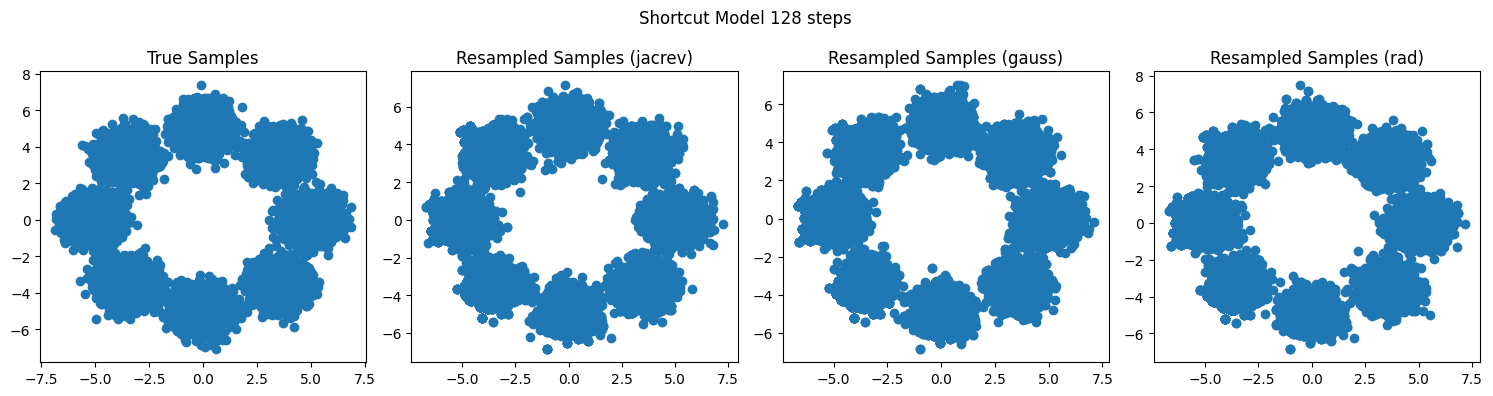

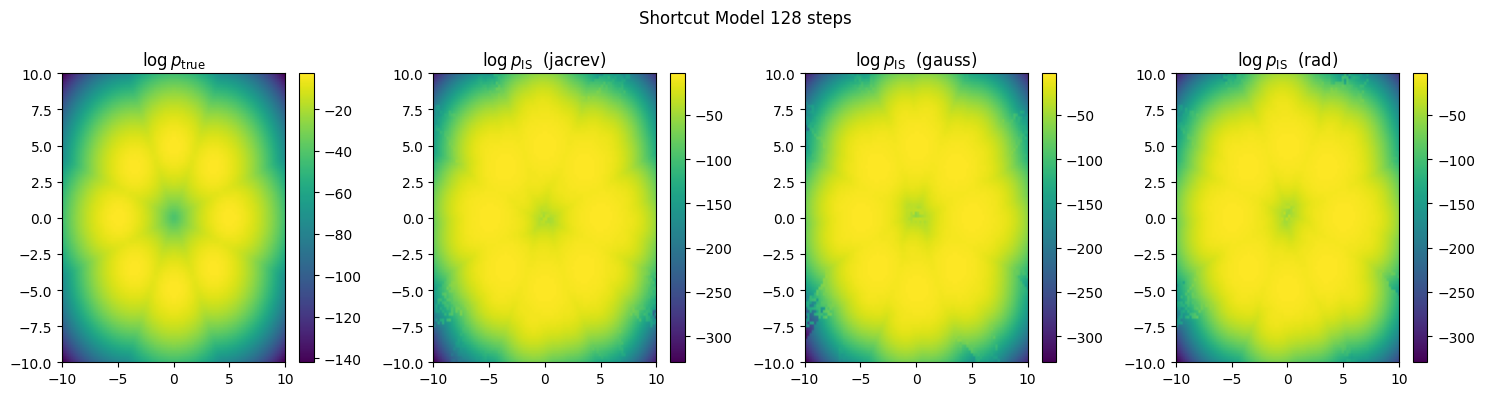

<Figure size 640x480 with 0 Axes>

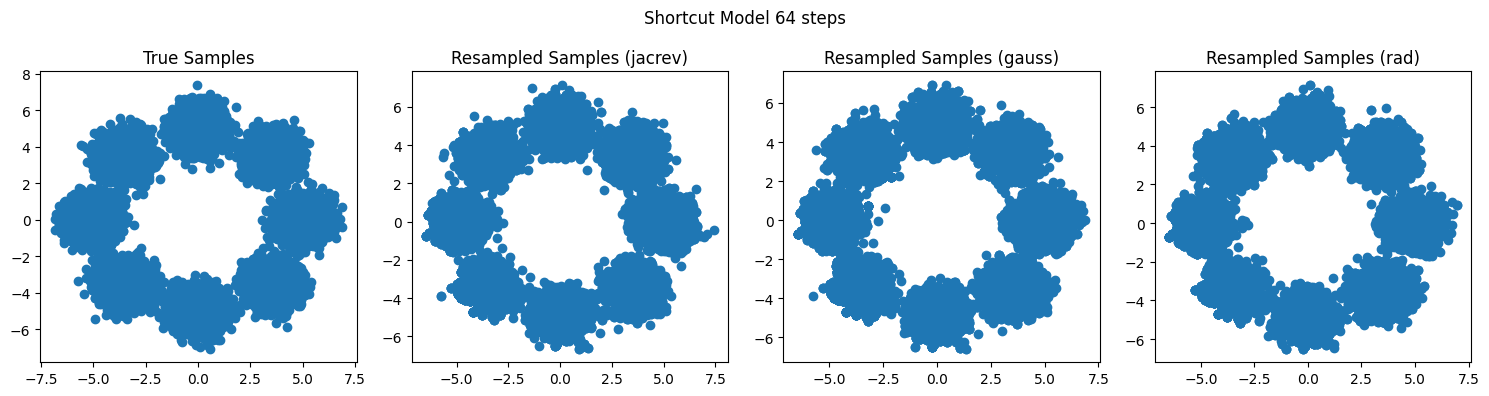

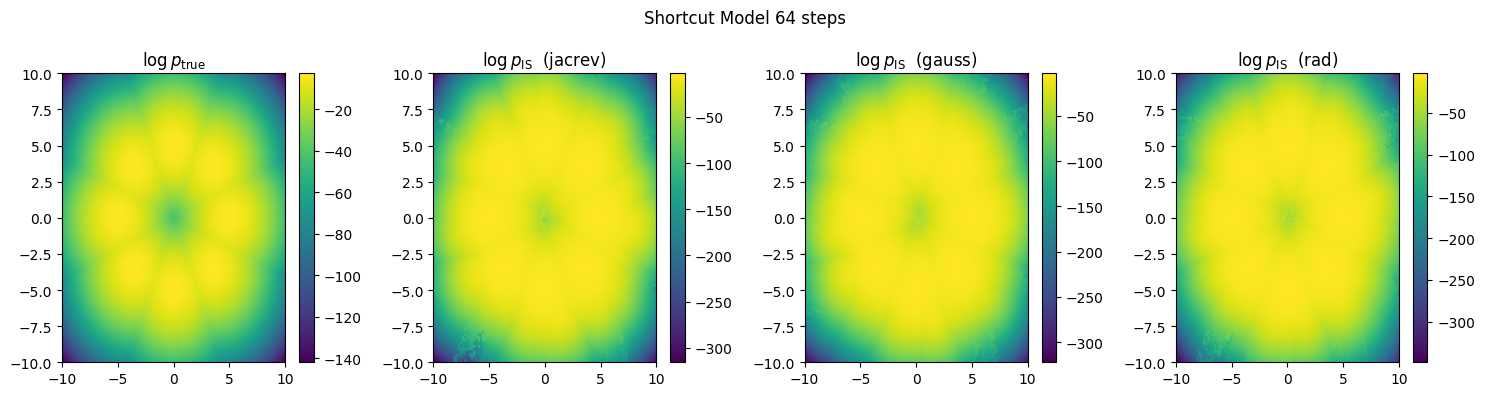

<Figure size 640x480 with 0 Axes>

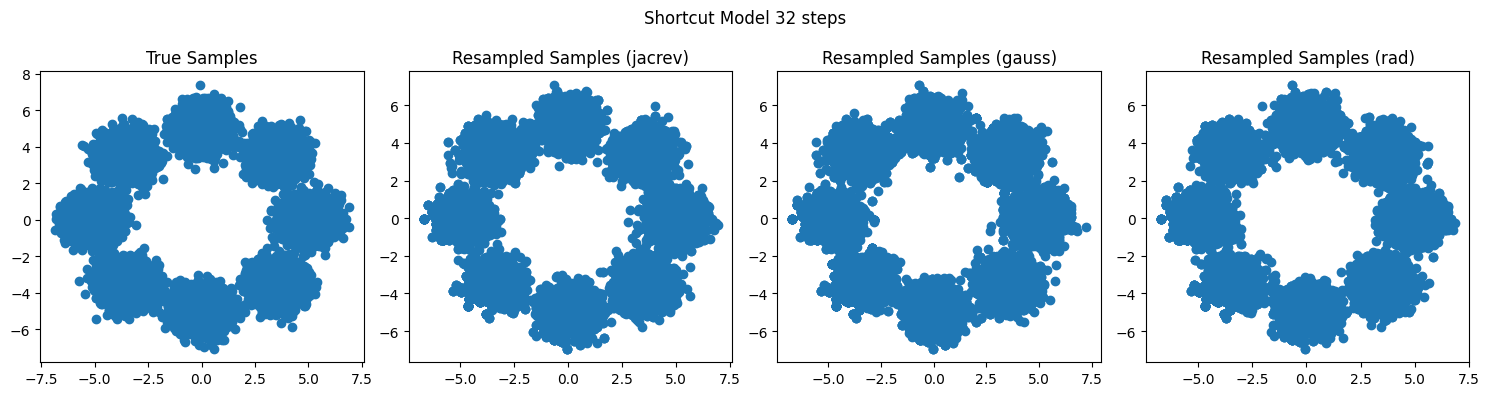

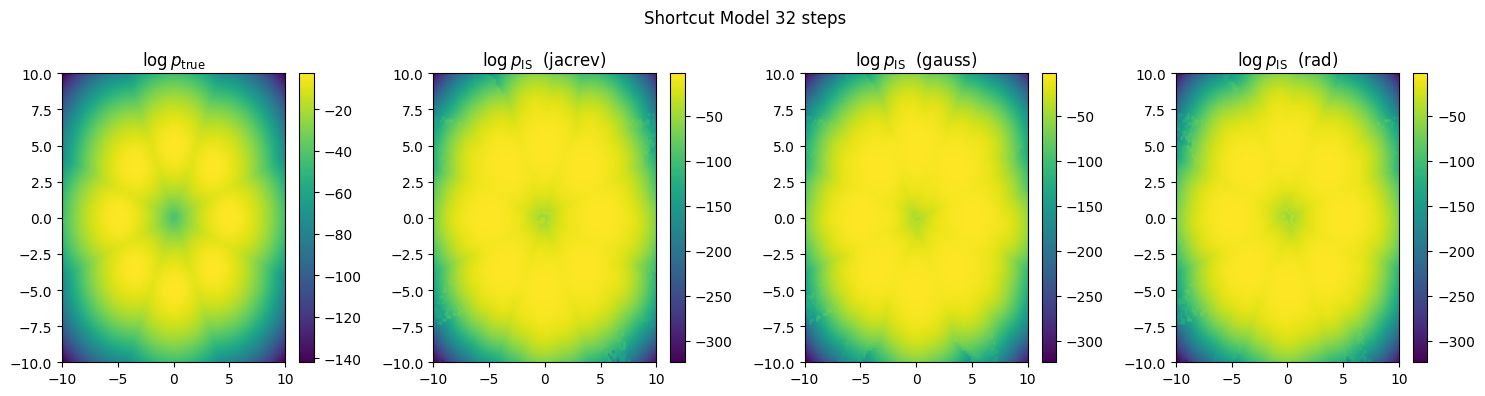

<Figure size 640x480 with 0 Axes>

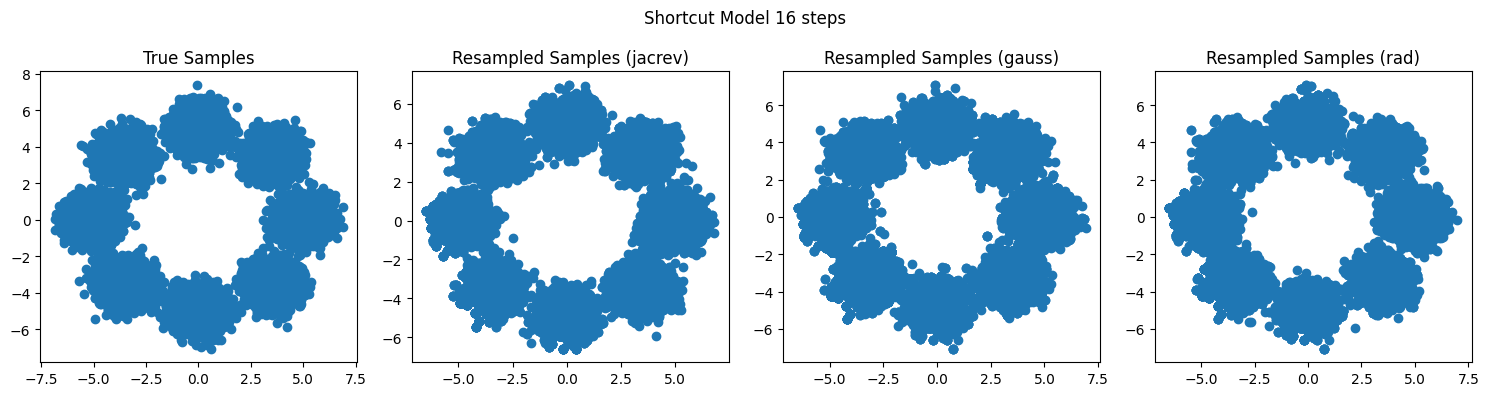

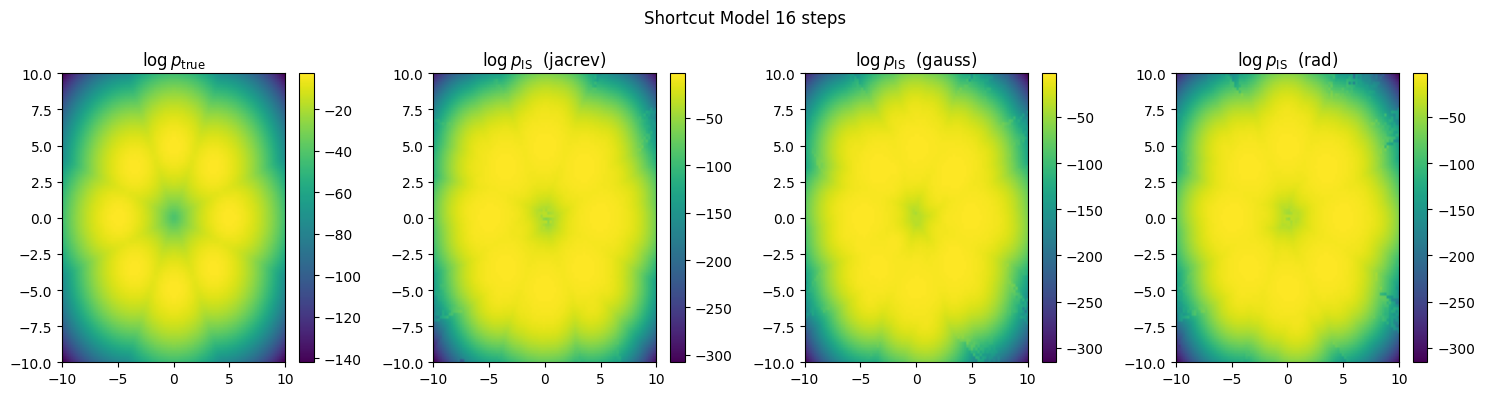

<Figure size 640x480 with 0 Axes>

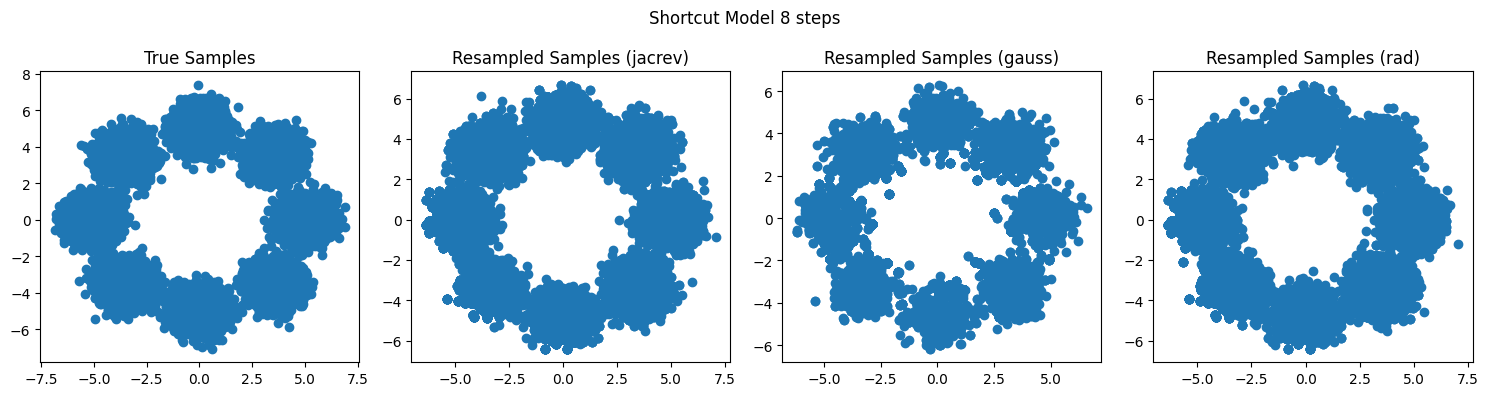

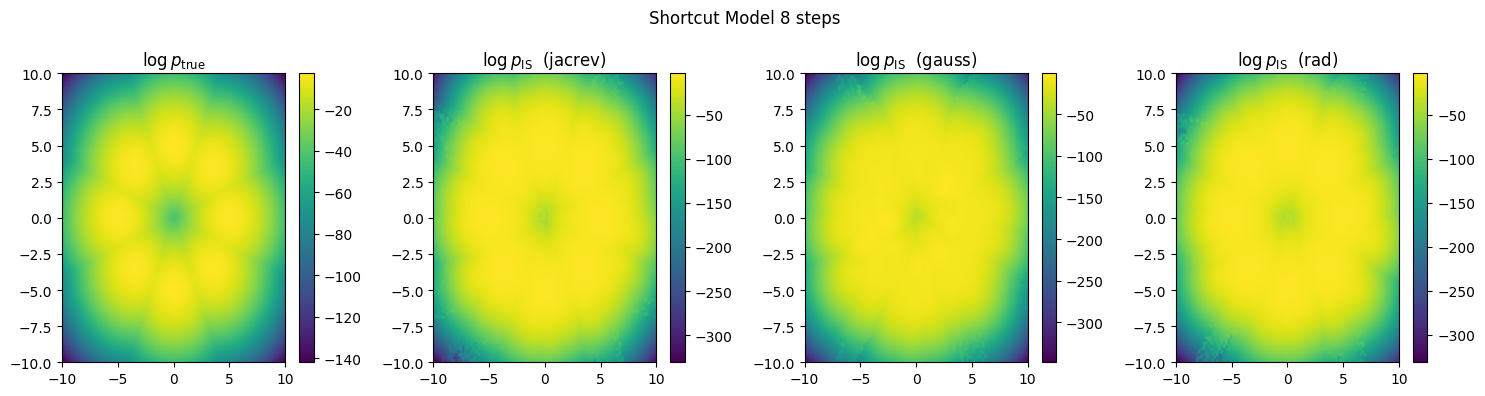

<Figure size 640x480 with 0 Axes>

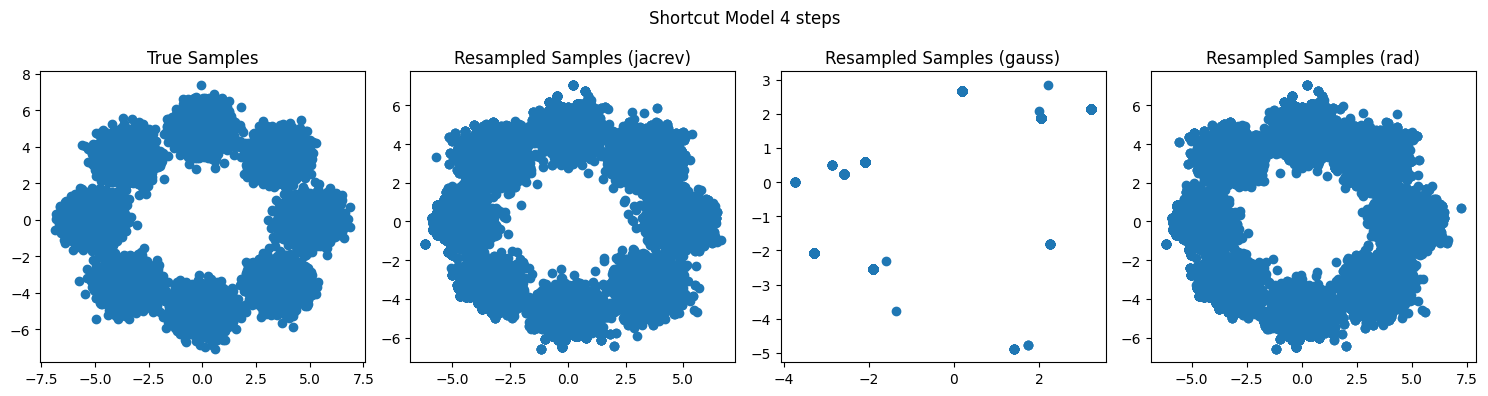

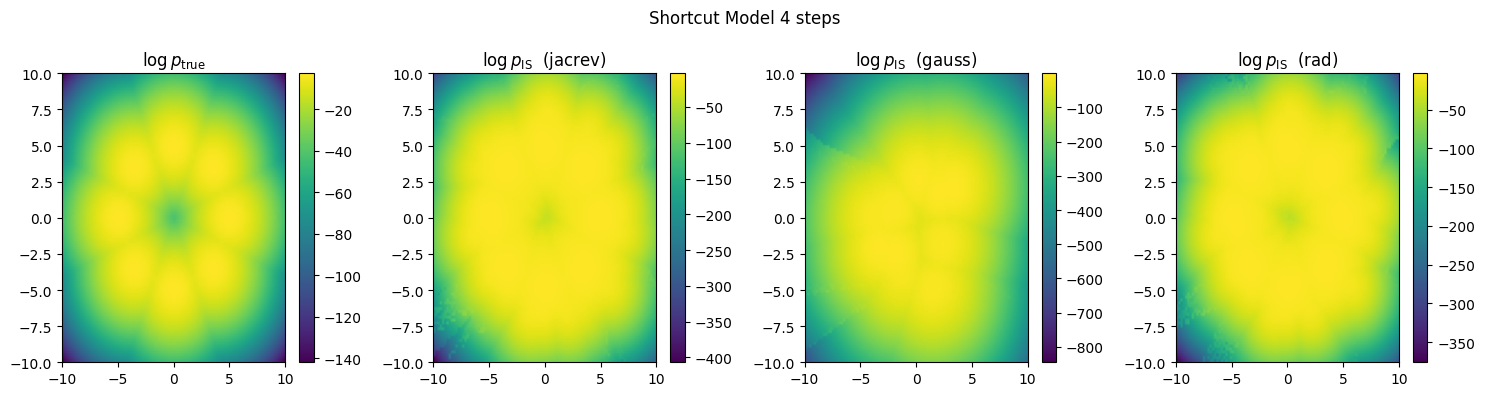

<Figure size 640x480 with 0 Axes>

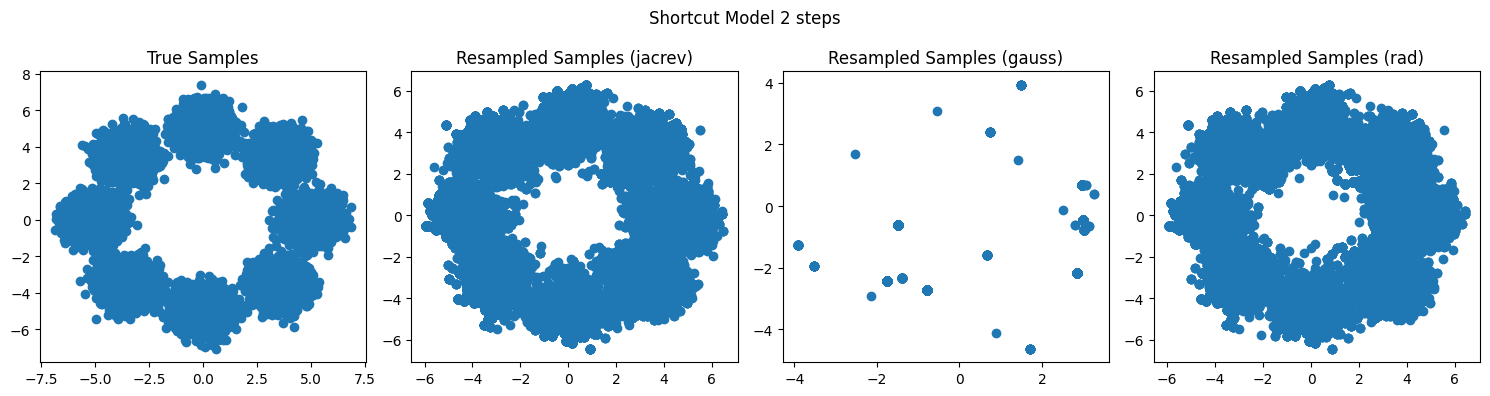

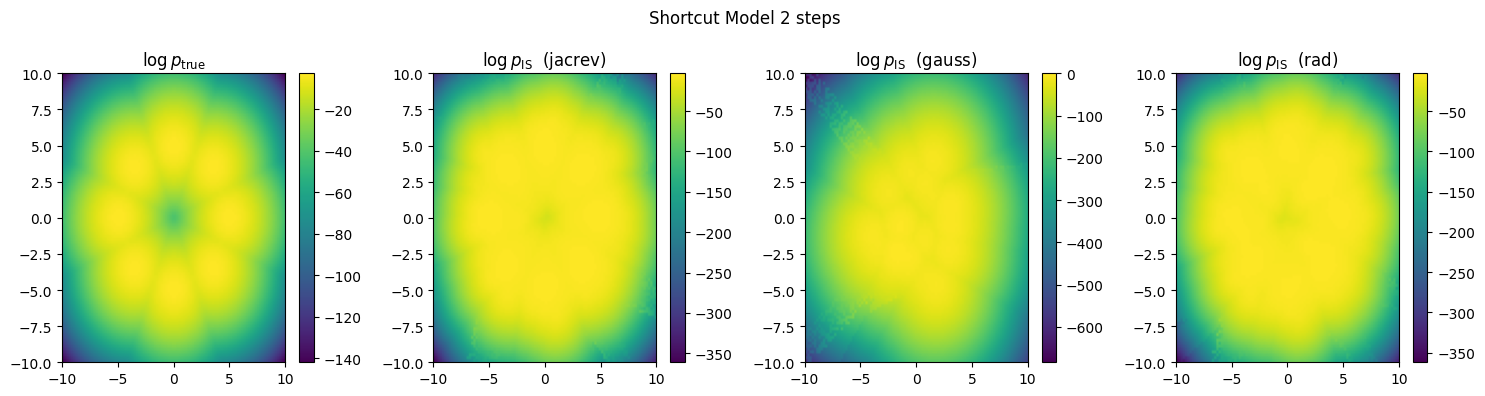

<Figure size 640x480 with 0 Axes>

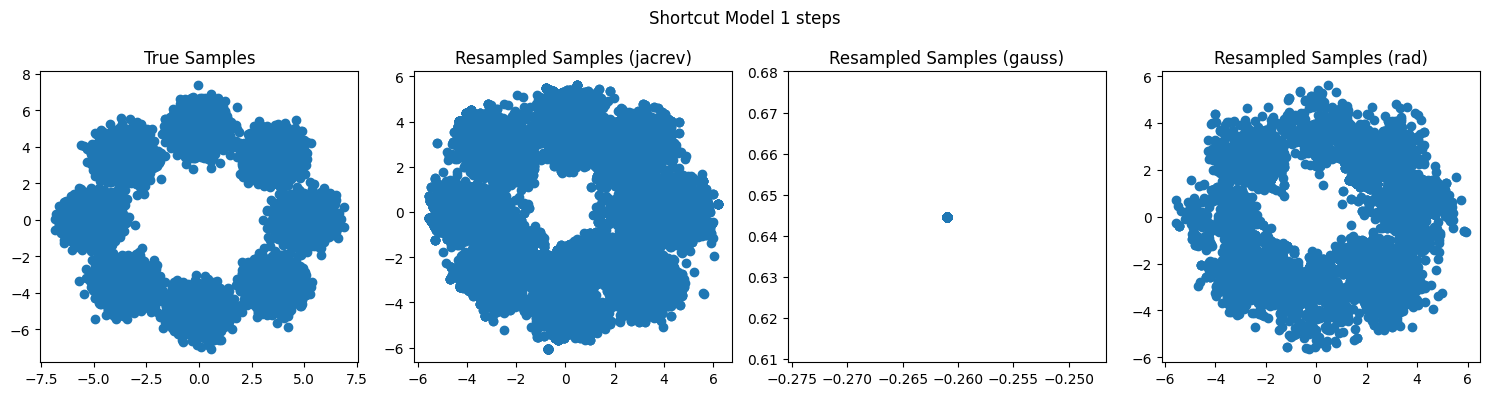

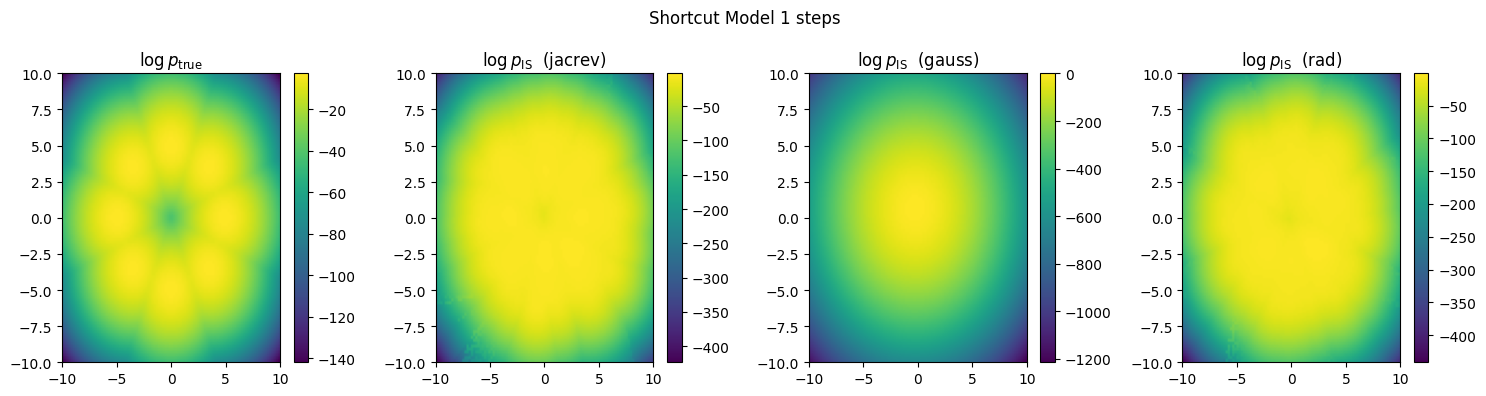

<Figure size 640x480 with 0 Axes>

In [35]:
from torch.distributions import MultivariateNormal
from sklearn.neighbors import KernelDensity

prior = MultivariateNormal(torch.zeros(dim, device=device), torch.eye(dim, device=device))

@torch.no_grad()
def shortcut_inference(model, num_samples=16768, denoise_timesteps=128, no_shortcut=False):
    x0 = prior.sample((num_samples,))
    x = x0
    traj = []
    delta_t = 1.0 / denoise_timesteps
    div = 0.0
    div_gauss = 0.0
    div_rad = 0.0
    for i in range(denoise_timesteps):
        t = i / denoise_timesteps
        
        # Build t_vector with shape [batch_size].
        t_vector = torch.full((x.shape[0],), t, device=device, dtype=torch.float32)
        dt_flow = int(np.log2(denoise_timesteps))
        dt_base = torch.ones(x.shape[0], dtype=torch.int32, device=device) * dt_flow
        v = model(torch.cat([x, t_vector[:, None], dt_base[:, None]], dim=-1))

        def vecfield(y):
            t_in_func = t_vector[0].detach().unsqueeze(0)
            if no_shortcut:
                dt_base_in_func = torch.zeros_like(dt_base[0]).detach().unsqueeze(0)
            else:
                dt_base_in_func = dt_base[0].detach().unsqueeze(0)
            out_v = model(torch.cat([y.unsqueeze(0), t_in_func[:, None], dt_base_in_func[:, None]], dim=-1)).squeeze()
            return out_v

        # Exact Div Calculation 
        jac_fn = torch.func.jacrev(vecfield)
        jac = torch.func.vmap(jac_fn)(x)
        div = div + (jac[:, 0, 0] + jac[:, 1, 1]) * delta_t # God Bless ChatGPT

        # Hutch Div Calculation (Gaussian)
        eps_gauss = torch.randn_like(x)
        jac_gauss = torch.vmap(div_fn_hutch_trace(vecfield))(x, eps_gauss)
        div_gauss = div_gauss + jac_gauss * delta_t

        # Hutch Div Calculation (Rademacher)
        eps_rad = torch.randint_like(x, low=0, high=2).float() * 2 - 1.0
        jac_rad = torch.vmap(div_fn_hutch_trace(vecfield))(x, eps_rad)
        div_rad = div_rad + jac_rad * delta_t

        # Euler sampling
        x = x + v * delta_t
        traj.append(x.detach())

    logp_dict = {} 
    traj = torch.stack(traj).detach()
    logp_dict["true"] = eight_normal_log_prob(traj[-1]).flatten().detach()
    logp_dict["jacrev"] = (prior.log_prob(x0) - div).flatten().detach()
    logp_dict["gauss"] = (prior.log_prob(x0) - div_gauss).flatten().detach()
    logp_dict["rad"] = (prior.log_prob(x0) - div_rad).flatten().detach()
    return traj, logp_dict

@torch.no_grad()
def importance_sample(samples, true_lop_prob, est_log_prob, num_samples=16768):

    importance_weights = torch.exp(true_lop_prob - est_log_prob)
    importance_weights = importance_weights / torch.sum(importance_weights)
    resampled_samples = samples[torch.multinomial(importance_weights, num_samples, replacement=True)]

    return resampled_samples

def kde_log_density(samples, grid, bandwidth=0.3):

    kde = KernelDensity(kernel='gaussian', bandwidth=bandwidth).fit(samples)

    # Evaluate log density on the grid
    log_density = kde.score_samples(grid)

    # Reshape for plotting
    log_density_2d = log_density.reshape(X.shape)

    return log_density_2d

# Create a grid for evaluation
xmin, ymin = -10, -10
xmax, ymax = 10, 10
grid_density = 100
X, Y = np.meshgrid(np.linspace(xmin, xmax, grid_density),
                   np.linspace(ymin, ymax, grid_density))
grid = np.vstack([X.ravel(), Y.ravel()]).T

def plot_density_2d(ax, log_density_2d, title):
    sc = ax.imshow(log_density_2d, origin='lower',
               extent=[xmin, xmax, ymin, ymax],
               aspect='auto', cmap='viridis')
    fig.colorbar(sc, ax=ax)
    ax.set_title(title)

num_samples = 4192 * 8
resampling_factor = 1

log2_sections = int(np.log2(M)) + 1
dt_range = torch.arange(log2_sections, device=device, dtype=torch.int32).flip(dims=(0,))

true_samples = eight_normal_sample(num_samples).numpy()
true_log_density_2d = eight_normal_log_prob(torch.tensor(grid)).numpy().reshape(X.shape)

plot_type = "scatter"

for denoise_timestep_iter in dt_range:

    denoise_timestep_iter = int((2.0 ** denoise_timestep_iter))

    shortcut_traj, shortcut_logp_dict = shortcut_inference(model, num_samples=num_samples, denoise_timesteps=denoise_timestep_iter)
    shortcut_samples = shortcut_traj[-1]

    samples_dict = {}
    for est_name in ["jacrev", "gauss", "rad"]:
        resampled_samples = importance_sample(shortcut_samples, shortcut_logp_dict["true"], shortcut_logp_dict[est_name], num_samples=num_samples * resampling_factor)
        samples_dict[est_name] = resampled_samples

    ## Scatter Plot
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
    fig.suptitle(f"Shortcut Model {denoise_timestep_iter} steps")

    sc1 = ax1.scatter(true_samples[:,0], true_samples[:,1])
    ax1.set_title("True Samples")
    for samples, name, ax in zip(samples_dict.values(), samples_dict.keys(), [ax2, ax3, ax4]):
        sc = ax.scatter(samples[:,0], samples[:,1])
        ax.set_title(f"Resampled Samples ({name})")

    # Density Plot
    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
    fig.suptitle(f"Shortcut Model {denoise_timestep_iter} steps")

    plot_density_2d(ax1, true_log_density_2d, r"$\log p_{\text{true}}$")
    for samples, est_name, ax in zip(samples_dict.values(), samples_dict.keys(), [ax2, ax3, ax4]):
        log_density_2d = kde_log_density(samples, grid)
        #plot_density_2d(ax, true_log_density_2d - log_density_2d, r"$\log p_{\text{true}}/p_{\text{IS}}$" + f"  ({est_name})")
        plot_density_2d(ax, log_density_2d, r"$\log p_{\text{IS}}$" + f"  ({est_name})")

    plt.show()
    plt.clf()


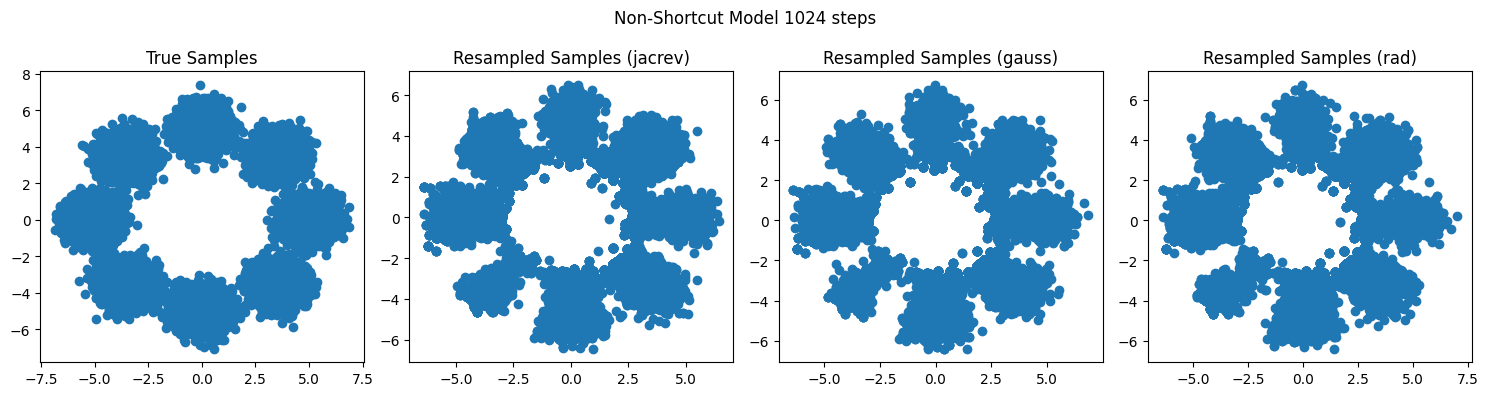

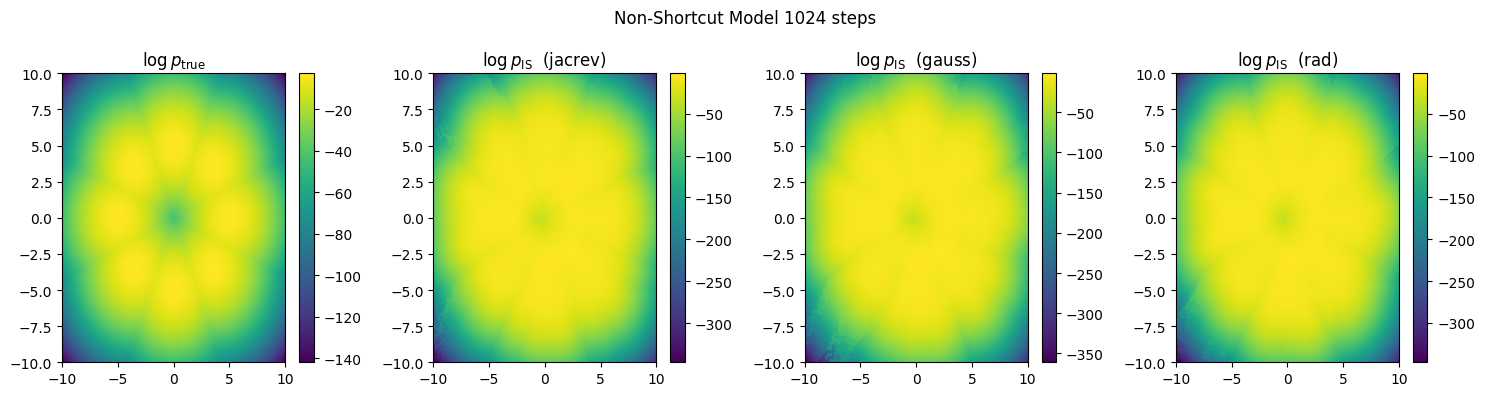

<Figure size 640x480 with 0 Axes>

In [36]:
denoise_timestep_iter = 1024

no_shortcut_traj, no_shortcut_logp_dict = shortcut_inference(model, num_samples=num_samples, denoise_timesteps=denoise_timestep_iter, no_shortcut=True)
no_shortcut_samples = no_shortcut_traj[-1]

samples_dict = {}
for est_name in ["jacrev", "gauss", "rad"]:
    resampled_samples = importance_sample(no_shortcut_samples, no_shortcut_logp_dict["true"], no_shortcut_logp_dict[est_name], num_samples=num_samples * resampling_factor)
    samples_dict[est_name] = resampled_samples

## Scatter Plot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
fig.suptitle(f"Non-Shortcut Model {denoise_timestep_iter} steps")

sc1 = ax1.scatter(true_samples[:,0], true_samples[:,1])
ax1.set_title("True Samples")
for samples, name, ax in zip(samples_dict.values(), samples_dict.keys(), [ax2, ax3, ax4]):
    sc = ax.scatter(samples[:,0], samples[:,1])
    ax.set_title(f"Resampled Samples ({name})")

# Density Plot
fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 4), tight_layout=True)
fig.suptitle(f"Non-Shortcut Model {denoise_timestep_iter} steps")

plot_density_2d(ax1, true_log_density_2d, r"$\log p_{\text{true}}$")
for samples, est_name, ax in zip(samples_dict.values(), samples_dict.keys(), [ax2, ax3, ax4]):
    log_density_2d = kde_log_density(samples, grid)
    #plot_density_2d(ax, true_log_density_2d - log_density_2d, r"$\log p_{\text{true}}/p_{\text{IS}}$" + f"  ({est_name})")
    plot_density_2d(ax, log_density_2d, r"$\log p_{\text{IS}}$" + f"  ({est_name})")

plt.show()
plt.clf()